In [2]:
import MAS_library as MASL
import numpy as np
import scipy
import h5py as h5
import matplotlib.pyplot as plt
import readgadget
from collections import defaultdict
from mpi4py import MPI
import random
import psutil
import os


def nested_dict(n, type):
    """
    This function creates a nested dictionary with a specified depth and default value type.

    Parameters:
        n (int): an integer representing the depth of the nested dictionary.
        type: the default value type for the nested dictionary.

    Returns:
        A nested dictionary with a depth of 'n' and default values of the specified type.
    """
    if n == 1:
        return defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))
    
data = nested_dict(5, list)

class massive_neutrinos:
    """
    Class for massive neutrino project
    """
    def __init__(self, boxsize):
        self.comm = MPI.COMM_WORLD
        self.boxsize = boxsize;
        return


    def norm(self, x):
        """ norm of a vector """
        return np.sqrt(sum(x_i*x_i for x_i in x));


    def dist(self, x, y):
        """Distance of two points"""
        return self.norm(np.subtract(x,y)) ;

    def statistics(self, x):
        """Given a vector it returns the average and std of the list! """
        return (np.average(x),np.std(x));

    def halo_selection(self, data_address, string, mass_limit, extra_columns=False):
        """ outputting a halo population obtained by a mass limit and whether we want larger or smaller halos.
            input: data (halo catalogue from Rockstar), a string being + or -, and mass limit in solar mass.
            output: A new catalogue with [x,y,z,v_x,v_y,v_z] and additional columns of[Rvir,M200b] of halo population if requested!
        """
        data = np.loadtxt(data_address);
        if (string == "+"):
            condition = data[:,20]> mass_limit;
            if extra_columns:
                halo_pop = np.zeros((np.shape(data[condition])[0],8))
            else:
                halo_pop = np.zeros((np.shape(data[condition])[0],6))
            for i in range(6):
                halo_pop[:,i] = data[condition][:,8+i]
            if (extra_columns):
                halo_pop[:,6] = data[condition][:,5] # R_vir
                halo_pop[:,7] = data[condition][:,20] # Mass
        elif (string == "-"):
            condition = data[:,20]<= mass_limit;
            if extra_columns:
                halo_pop = np.zeros((np.shape(data[condition])[0],8))
            else:
                halo_pop = np.zeros((np.shape(data[condition])[0],6))
            for i in range(6):
                halo_pop[:,i] = data[condition][:,8+i]
            if (extra_columns):
                halo_pop[:,6] = data[condition][:,5] # R_vir
                halo_pop[:,7] = data[condition][:,20] # Mass
 
        elif (string == "all"):
            if extra_columns:
                halo_pop = np.zeros((np.shape(data)[0],8))
            else:
                halo_pop = np.zeros((np.shape(data)[0],6))
            for i in range(6):
                halo_pop[:,i] = data[:,8+i]
            if (extra_columns):
                halo_pop[:,6] = data[:,5] # R_vir
                halo_pop[:,7] = data[:,20] # Mass

        return halo_pop;

    def sum_vel_dot_vbulk(self, vel, velocity_bulk):
        """computing v_i . v_bulk for halos/particle using the bulk velocity and returning the sum of all dot product and number of halos in that cell."""
        product = np.zeros((np.shape(vel)[0]));
        # for i in range(np.shape(vel)[0]):
        #     product += np.dot(vel[i,:], velocity_bulk) # velocity bulk is an 3D array while vel =  N_halos x 3
        avg = np.mean(np.dot(vel, velocity_bulk))
        std = np.std(np.dot(vel, velocity_bulk))
        return [avg, std, np.shape(vel)[0]] # returns sum of all dot product and number of halos in that cell

    def vels_in_cell(self, ngrid, pos, vel, sub_box_index):
        boxsize = self.boxsize;
        """outputting the velocity of halos in the given sub-box """
        condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
        condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
        condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
        condition_tot = (condition_x) & (condition_y) & (condition_z)
        vel_halos =vel[condition_tot];
        # pos_halos =pos[condition_tot]# For test you can output pos[vel_halos, pos_halos];
        return vel_halos

    def velocity_bulk(self, ngrid, pos,vel, sub_box_index):
        boxsize = self.boxsize;
        """computing the bulk velocity in a sub-box using the velocities of objects"""
        condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
        condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
        condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
        condition_tot = (condition_x) & (condition_y) & (condition_z)
        vel_grids= np.array([np.average(vel[condition_tot,0]),np.average(vel[condition_tot,1]),np.average(vel[condition_tot,2])])
        sigma_vel_grids= np.array([np.std(vel[condition_tot,0]),np.std(vel[condition_tot,1]),np.std(vel[condition_tot,2])])
        return [vel_grids,sigma_vel_grids];


    def catalogue_header(self, address, column=-1):
        """Takes the address of the halo catalogue and reads the whole header by default. If the column is specified then just prints the corresponding column!"""
        f = open(address)
        header = f.readline()
        header_list = header.split(' ') #list of columns
        if column==-1:
            for i in range(np.shape(header_list)[0]):
                print(str(i)+":"+header_list[i])
        if column!=-1:
            print(str(column)+":"+header_list[column])

    def gadget_load(self, snapshot, ptype=[1]):
        """Takes the address of the a gadget 2 snapshot and returns the pos and velocity of particles!
           input: snapshot address, ptype -- > [1] for cdm and [2] for neutrinos!
        """
        pos = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
        vel = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
        # ids = readgadget.read_block(snapshot, "ID  ", ptype)-1   #IDs starting from 0
        return np.array([pos,vel])


    def Random_sub_box(self, ngrid, number):
        """Takes the number of grids and return N randomly chosen sub-box indices!
        """
        res = np.zeros((number,3)).astype(int)
        for i in range(number):
            res[i] = random.sample(range(0, ngrid), 3)       
        return res

    def data_sub_boxes(self, sub_box_lists, ngrid, pos_pcl, vel_pcl, pos_p1, vel_p1, pos_p2, vel_p2):
        """
        Computing alpha and sigma_alpha for each sub-box -- returning all alphas for number of sub-boxes!
        Input: 
        - index of sub-boxes we want to consider!
        - ngrid :  Number of grids = the resolution we want to compute alpha over.
        - pos of particles we want to compute the bulk velocity from  -- N x 3 array containing x, y, z of pcls
        - vel of particles we want to compute the bulk velocity from -- N x 3 array containing v_x, v_y, v_z 
        - pos_p1: position of halo population 1, N_p1 x 3 array containing [x, y, z] for population 1
        - vel_p1: position of halo population 1, N_p1 x 3 array containing [vx, vy, vz] for population 1
        - pos_p2: position of halo population 2, N_p1 x 3 array containing [x_p2, y_p2, z_p2] for population 1
        - vel_p2: velocity of halo population 2, N_p1 x 3 array containing [vx_p2, vy_p2, vz_p2] for population 1
        output:
        - An array containing [index of sub-box, average of alpha, std of alpha]
        """
        boxsize = self.boxsize;
        data=[]
        for i in range (np.shape(sub_box_lists)[0]):
            sub_box_index = sub_box_lists[i]
            bulk_vel = self.velocity_bulk(ngrid, pos_pcl,vel_pcl, sub_box_index); # Bulk velocity using cdm/neutrino
            vels_p1 = self.vels_in_cell(ngrid, pos_p1, vel_p1, sub_box_index);# velocity of population 1
            vels_p2 = self.vels_in_cell(ngrid, pos_p2, vel_p2, sub_box_index); # velocity of population 2
            # ## computing v_b.v_i information for two populations!
            vdvb_p1 = self.sum_vel_dot_vbulk(vels_p1, bulk_vel); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
            vdvb_p2 = self.sum_vel_dot_vbulk(vels_p2, bulk_vel);
            data.append([sub_box_index, vdvb_p1[0], vdvb_p2[0], vdvb_p1[1], vdvb_p2[1], vdvb_p1[2],  vdvb_p2[2]]);
            # [sub-box index, <v_i,v_b> population 1, <v_i,v_b> population 2, sigma v_i.v_b pop1, sigma v_i.v_b pop2, number of halos of pop1, number of halos of pop2]
        return data
    

    def Parallelized_alpha_sub_boxes(self, sub_box_lists, ngrid, pos_pcl, vel_pcl, pos_p1, vel_p1, pos_p2, vel_p2):
        """
        Parallelizing sub-boxes over number of CPUs and computing alpha and sigma_alpha for each sub-box -- returning all alphas for number of sub-boxes!
        Input: 
        - index of sub-boxes we want to consider!
        - ngrid :  Number of grids = the resolution we want to compute alpha over.
        - pos of particles we want to compute the bulk velocity from  -- N x 3 array containing x, y, z of pcls
        - vel of particles we want to compute the bulk velocity from -- N x 3 array containing v_x, v_y, v_z 
        - pos_p1: position of halo population 1, N_p1 x 3 array containing [x,y,z] for population 1
        - vel_p1: position of halo population 1, N_p1 x 3 array containing [vx,vy,vz] for population 1
        - pos_p2: position of halo population 2, N_p1 x 3 array containing [x_p2,y_p2,z_p2] for population 1
        - vel_p2: velocity of halo population 2, N_p1 x 3 array containing [vx_p2,vy_p2,vz_p2] for population 1
        output:
        - An array containing [index of sub-box, average of alpha, std of alpha]
        """
        comm = self.comm;
        boxsize = self.boxsize;
        rank = comm.Get_rank();
        size = comm.Get_size();
        t_start = MPI.Wtime()
        data=[]
        if rank == 0:
            a_row = sub_box_lists.shape[0]
            if a_row >= size:
                split = numpy.array_split(sub_box_lists, size, axis=0)
        else:
            split = None
        split = comm.scatter(split, root=0) # This scatters each part of vector over each CPU! The vector was initially produced based on number of CPUs.
        # split = numpy.dot(split, b)
        for i in range(np.shape(split)):
            sub_box_index = split[i];
            bulk_vel = velocity_bulk(ngrid, boxsize, pos,vel, sub_box_index); # Bulk velocity using cdm/neutrino
            vels_p1 = vels_in_cell(ngrid, boxsize, pos, vel, sub_box_index);# alpha for population 1
            vels_p2 = vels_in_cell(ngrid, boxsize, pos, vel, sub_box_index); # alpha for population 2

            alphas_p1 = alpha_list(vels_p1, bulk_vel);
            alphas_p2 = alpha_list(vels_p2, bulk_vel);

            data.append(sub_box_index, np.average(alpha_p1), np.average(alpha_p2), np.std(alpha_p1), np.std(alpha_p2));
            # data containing sub-nox index, average of alpha_pi and std of alphas!

        data = comm.gather(data, root=0)
        if rank == 0:
            result = numpy.vstack(data)
            t_diff_multi = MPI.Wtime() - t_start    ### Stop stopwatch ###
            print('Time taken one core:', t_diff_one, 'Time taken one multicore:', t_diff_multi)
        return result

def memory():
    psutil.virtual_memory()
    # you can convert that object to a dictionary 
    dict(psutil.virtual_memory()._asdict())
    pid = os.getpid()
    python_process = psutil.Process(pid)
    # you can have the percentage of used RAM
    memoryUse = python_process.memory_info()[0]/2.**30  # memory use in GB...I think
    print('memory use:', memoryUse, 'GB, percentage: ',psutil.virtual_memory().percent)
    

## Defining CLASS and loading files!

In [3]:
%%time
memory();


for sim_size in ['L_512_N_256']:
    ##### parameters
    boxsize=512.0;
    mass_limit = 1.5*1.e13;
    obj = massive_neutrinos(boxsize);
    
    ### type of bulk species
    for bulk_species in ['cdm']:
        for snap_num in [3]: # the snapshot number start from high redshift
            for sim in ['Mn_0d6_nu_pcls']:
                ######################
                ## particles read
                ######################
                if bulk_species=='cdm':
                    print("bulk chosen to cdm")
                    snapshot = './../Simulations///'+sim_size+'/'+sim+'/output/snap00'+str(snap_num)+'_cdm'
                    #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
                    ptype = [1]
                    cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                    data[sim_size][sim][bulk_species]['pos'] = cdm_pcl[0]; 
                    data[sim_size][sim][bulk_species]['vel'] = cdm_pcl[1];
                ######################
                ### Neutrinos read:
                ######################
                elif bulk_species=='nu':
                    print("bulk chosen to neutrino")
                    ptype=[1];
                    snapshot = './../Simulations//'+sim_size+'//'+sim+'/output/snap00'+str(snap_num)+'_ncdm0'
                    nu_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                    data[sim_size][sim][bulk_species]['pos'] = nu_pcl[0]; 
                    data[sim_size][sim][bulk_species]['vel'] = nu_pcl[1];
                ######################
                ## halo read
                ######################
                halo_address ='./../Simulations/'+sim_size+'/'+sim+'/output/halos/out_'+str(snap_num)+'.list'
                #pop 1
                halo_p1 = obj.halo_selection(halo_address, '+', mass_limit);
                data[sim_size][sim]['halo_p1']['pos'] = halo_p1[:,:3]
                data[sim_size][sim]['halo_p1']['vel'] = halo_p1[:,3:6]
                #pop 2
                halo_p2 = obj.halo_selection(halo_address, '-', mass_limit)
                data[sim_size][sim]['halo_p2']['pos'] = halo_p2[:,:3]
                data[sim_size][sim]['halo_p2']['vel'] = halo_p2[:,3:6]            
                #pop all
                halo_all = obj.halo_selection(halo_address, 'all', mass_limit)
                data[sim_size][sim]['halo']['pos'] = halo_all[:,:3]
                data[sim_size][sim]['halo']['vel'] = halo_all[:,3:6]

print("bulk pcl=",bulk_species,", Number of bulk pcls:",np.shape( data[sim_size][sim][bulk_species]['pos'])[0], "number of halos:", np.shape(data[sim_size][sim]['halo']['pos'])[0])
print("number of halos pop1: ", np.shape(data[sim_size][sim]['halo_p1']['pos'])[0]," number of pop2:", np.shape(data[sim_size][sim]['halo_p2']['pos'])[0])


memory use: 0.14636993408203125 GB, percentage:  7.4
bulk chosen to cdm
bulk pcl= cdm , Number of bulk pcls: 16777216 number of halos: 9731
number of halos pop1:  4653  number of pop2: 5078
CPU times: user 356 ms, sys: 363 ms, total: 719 ms
Wall time: 726 ms


# Computing alphas

In [ ]:
%%time
memory();

##########
number_smaples = 25;
sim_size = 'L_512_N_256'
sim = 'Mn_0d6_nu_pcls'
nu_consider = "yes"
##########

weight_tot=0;
alpha_halos_nu_tmp = 0
vb_dot_vb_nu = 0
alpha_halos_cdm_tmp = 0
alpha_halos_cdm=0;
alpha_halos_cdm_weighted=0;
alpha_halos_cdm_tmp_weighted=0;
alpha_halos_nu_cdm=0;
vb_dot_vb_cdm=0;
alpha_halos_cdm=0;
alpha_halos_cdm_v1 = 0
alpha_halos_nu_v1 = 0
alpha_halos_halos_tmp=0
alpha_halos_halos_tmp_weighted=0
vb_dot_vb_halos=0
alpha_halos_halos=0
alpha_halos_halos_weighted=0
alpha_halos_nu_tmp_weighted=0
for ngrid in [10]:
    sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
    for i in range(number_smaples):
        sub_box_index = sub_box_lists[i]
        ##############################
        ##### pcl velocities in each cell
        ##############################
        bulk_species = 'cdm'
        pos_cdm = data[sim_size][sim][bulk_species]['pos']
        vel_cdm = data[sim_size][sim][bulk_species]['vel']
        cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        
        ##### halos velocities in each cell
        pos_halo_all = data[sim_size][sim]['halo']['pos']
        vel_halo_all = data[sim_size][sim]['halo']['vel']
        halos_vels_i = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        # print(halos_vels)
        
        #### Bulk velocity computation
        bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos_halo_all, vel_halo_all, sub_box_index) # Bulk velocities using halos
        bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm, vel_cdm, sub_box_index) # Bulk velocities using cdm
        
        ### all bulk velocities!
        bulk_vel_cdm.append([ngrid, sub_box_index,bulk_vel_cdm_i] ) # gives the bulk velocity and its 1 sigma as an array!
        bulk_vel_halos.append([ngrid, sub_box_index, bulk_vel_halos_i] ) # gives the bulk velocity and its 1 sigma as an array!

        if nu_consider == "yes":
            bulk_vel_nu_i = obj.velocity_bulk(ngrid, pos_nu, vel_nu, sub_box_index)
            bulk_vel_nu.append([ngrid, sub_box_index, bulk_vel_nu_i]) # gives the bulk velocity and its 1 sigma as an array!

        

        ## computing alpha using just np.dot(vel[i,:], velocity_bulk[0])/np.dot(velocity_bulk[0],velocity_bulk[0]) in each cell!
        alpha_halos_cdm_v1 = alpha_halos_cdm_v1 + np.average(obj.alpha_list(halos_vels_i, bulk_vel_cdm_i))
        alpha_halos_nu_v1 = alpha_halos_nu_v1 + np.average(obj.alpha_list(halos_vels_i, bulk_vel_nu_i));

        ## computing v_i.v_bulk for each cell and sum over all cells at the end and divide by b_b.v_b
        if (obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_nu_i[0])[1] != 0):
            print("num=",obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_nu_i[0])[1])
            tmp = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_nu_i[0])[0][0];
            num_pop = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_nu_i[0])[1]
            ######
            weight = num_pop;
            alpha_halos_nu_tmp = alpha_halos_nu_tmp +  tmp;
            alpha_halos_nu_tmp_weighted = alpha_halos_nu_tmp_weighted +  tmp * weight;
            
            # weight_tot_nu = weight_tot +  weight; 
            vb_dot_vb_nu = vb_dot_vb_nu +  np.dot(bulk_vel_nu_i[0],bulk_vel_nu_i[0])*weight;
            
        #### cdm halos
        if (obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])[1] != 0):
            print("num=",obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])[1])
            tmp = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])[0][0];
            
            num_pop = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])[1]
            ######
            weight = num_pop;
            alpha_halos_cdm_tmp = alpha_halos_cdm_tmp + tmp;
            alpha_halos_cdm_tmp_weighted = alpha_halos_cdm_tmp_weighted +  tmp * weight;
            weight_tot_cdm = weight_tot +  weight; 
            vb_dot_vb_cdm = vb_dot_vb_cdm +  np.dot(bulk_vel_cdm_i[0],bulk_vel_cdm_i[0])*weight;
            print("v_i.v_b/v_b.v_b=",tmp/np.dot(bulk_vel_cdm_i[0],bulk_vel_cdm_i[0]))
            
            
        #### halos halos
        if (obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0])[1] != 0):
            print("num=",obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0])[1])
            tmp = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0])[0][0];
            num_pop = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0])[1]
            ######
            weight = num_pop;
            alpha_halos_halos_tmp = alpha_halos_halos_tmp + tmp;
            alpha_halos_halos_tmp_weighted = alpha_halos_halos_tmp_weighted +  tmp * weight;
            weight_tot_h = weight_tot +  weight; 
            vb_dot_vb_halos = vb_dot_vb_halos +  np.dot(bulk_vel_halos_i[0],bulk_vel_halos_i[0])*weight;
        # alpha_cdm_nu.append([ngrid, sub_box_index, obj.alpha_list(cdm_vels, bulk_vel_nu_i)]);
        # alpha_halos_cdm.append([ngrid, sub_box_index, obj.alpha_list_niayesh(vel_halo_all, bulk_vel_cdm_i)]);
        # alpha_halos_nu.append([ngrid, sub_box_index, obj.alpha_list_niayesh(vel_halo_all, bulk_vel_nu_i)]);
        # alpha_cdm_nu.append([ngrid, sub_box_index, obj.alpha_list_niayesh(cdm_vels, bulk_vel_nu_i)]);
        # alpha_halos_p1_cdm.append([sub_box_index, obj.alpha_list(vel_halo_p1, bulk_vel_cdm)]);
        # alpha_halos_p2_cdm.append([sub_box_index, obj.alpha_list(vel_halo_p2, bulk_vel_cdm)]);

    alpha_halos_nu = alpha_halos_nu_tmp/vb_dot_vb_nu;
    alpha_halos_nu_weighted = alpha_halos_nu_tmp_weighted/vb_dot_vb_nu;

    alpha_halos_cdm = alpha_halos_cdm_tmp/vb_dot_vb_cdm;
    alpha_halos_cdm_weighted = alpha_halos_cdm_tmp_weighted/vb_dot_vb_cdm;
 
    alpha_halos_halos = alpha_halos_halos_tmp/vb_dot_vb_halos;
    alpha_halos_halos_weighted = alpha_halos_halos_weighted/vb_dot_vb_halos;

    # print('alpha_FH(halos, nu) = ',alpha_halos_nu);
    # print('alpha_FH(halos, cdm) = ',alpha_halos_cdm_v1);

    # print('alpha_wighted(halos, nu) = ',alpha_halos_nu_weighted);
    print('alpha(halos, nu) = ',alpha_halos_nu);
    print('alpha_wighted(halos, nu) = ',alpha_halos_nu_weighted);

    print('alpha(halos, cdm) = ',alpha_halos_cdm);
    print('alpha_wighted(halos, cdm) = ',alpha_halos_cdm_weighted);

    print('alpha(halos, cdm) = ',alpha_halos_cdm);
    print('alpha_wighted(halos, cdm) = ',alpha_halos_cdm_weighted);


In [44]:
%%time
memory();

##########
number_smaples = 25;
sim_size = 'L_512_N_256'
sim = 'Mn_0d6_nu_pcls'
nu_consider = "yes"
##########

weight_tot=0;
alpha_halos_nu_tmp = 0
vb_dot_vb_nu = 0
alpha_halos_cdm_tmp = 0
alpha_halos_cdm=0;
alpha_halos_cdm_weighted=0;
alpha_halos_cdm_tmp_weighted=0;
alpha_halos_nu_cdm=0;
vb_dot_vb_cdm=0;
alpha_halos_cdm=0;
alpha_halos_cdm_v1 = 0
alpha_halos_nu_v1 = 0
alpha_halos_halos_tmp=0
alpha_halos_halos_tmp_weighted=0
vb_dot_vb_halos=0
alpha_halos_halos=0
alpha_halos_halos_weighted=0
alpha_halos_nu_tmp_weighted=0
for ngrid in [10]:
    ####
    # alpha_halos_nu=[]
    # alpha_cdm_nu=[]
    # alpha_halos_halos=[]
    bulk_vel_cdm=[]
    bulk_vel_nu=[]
    bulk_vel_halos=[];
    ####
    vel_dot_vbulk_array=[]
    ####
    sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
    for i in range(number_smaples):
        sub_box_index = sub_box_lists[i]
        ##############################
        ##### pcl velocities in each cell
        ##############################
        bulk_species = 'cdm'
        pos_cdm = data[sim_size][sim][bulk_species]['pos']
        vel_cdm = data[sim_size][sim][bulk_species]['vel']
        cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        
        ##############################
        ##### nu velocities in each cell
        ##############################
        if nu_consider == "yes":
            bulk_species = 'nu'
            pos_nu = data[sim_size][sim][bulk_species]['pos']
            vel_nu = data[sim_size][sim][bulk_species]['vel']
            nu_vels = obj.vels_in_cell(ngrid, pos_nu, vel_nu, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
       
        ##### halos velocities in each cell
        pos_halo_all = data[sim_size][sim]['halo']['pos']
        vel_halo_all = data[sim_size][sim]['halo']['vel']
        halos_vels_i = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        # print(halos_vels)
        
        #### Bulk velocity computation
        bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos_halo_all, vel_halo_all, sub_box_index)
        bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm, vel_cdm, sub_box_index)
        
        ### all bulk velocities!
        bulk_vel_cdm.append([ngrid, sub_box_index,bulk_vel_cdm_i] ) # gives the bulk velocity and its 1 sigma as an array!
        bulk_vel_halos.append([ngrid, sub_box_index, bulk_vel_halos_i] ) # gives the bulk velocity and its 1 sigma as an array!

        if nu_consider == "yes":
            bulk_vel_nu_i = obj.velocity_bulk(ngrid, pos_nu, vel_nu, sub_box_index)
            bulk_vel_nu.append([ngrid, sub_box_index, bulk_vel_nu_i]) # gives the bulk velocity and its 1 sigma as an array!

        

        ## computing alpha using just np.dot(vel[i,:], velocity_bulk[0])/np.dot(velocity_bulk[0],velocity_bulk[0]) in each cell!
        alpha_halos_cdm_v1 = alpha_halos_cdm_v1 + np.average(obj.alpha_list(halos_vels_i, bulk_vel_cdm_i))
        alpha_halos_nu_v1 = alpha_halos_nu_v1 + np.average(obj.alpha_list(halos_vels_i, bulk_vel_nu_i));

        ## computing v_i.v_bulk for each cell and sum over all cells at the end and divide by b_b.v_b
        if (obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_nu_i[0])[1] != 0):
            print("num=",obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_nu_i[0])[1])
            tmp = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_nu_i[0])[0][0];
            num_pop = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_nu_i[0])[1]
            ######
            weight = num_pop;
            alpha_halos_nu_tmp = alpha_halos_nu_tmp +  tmp;
            alpha_halos_nu_tmp_weighted = alpha_halos_nu_tmp_weighted +  tmp * weight;
            
            # weight_tot_nu = weight_tot +  weight; 
            vb_dot_vb_nu = vb_dot_vb_nu +  np.dot(bulk_vel_nu_i[0],bulk_vel_nu_i[0])*weight;
            
        #### cdm halos
        if (obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])[1] != 0):
            print("num=",obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])[1])
            tmp = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])[0][0];
            
            num_pop = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])[1]
            ######
            weight = num_pop;
            alpha_halos_cdm_tmp = alpha_halos_cdm_tmp + tmp;
            alpha_halos_cdm_tmp_weighted = alpha_halos_cdm_tmp_weighted +  tmp * weight;
            weight_tot_cdm = weight_tot +  weight; 
            vb_dot_vb_cdm = vb_dot_vb_cdm +  np.dot(bulk_vel_cdm_i[0],bulk_vel_cdm_i[0])*weight;
            print("v_i.v_b/v_b.v_b=",tmp/np.dot(bulk_vel_cdm_i[0],bulk_vel_cdm_i[0]))
            
            
        #### halos halos
        if (obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0])[1] != 0):
            print("num=",obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0])[1])
            tmp = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0])[0][0];
            num_pop = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0])[1]
            ######
            weight = num_pop;
            alpha_halos_halos_tmp = alpha_halos_halos_tmp + tmp;
            alpha_halos_halos_tmp_weighted = alpha_halos_halos_tmp_weighted +  tmp * weight;
            weight_tot_h = weight_tot +  weight; 
            vb_dot_vb_halos = vb_dot_vb_halos +  np.dot(bulk_vel_halos_i[0],bulk_vel_halos_i[0])*weight;
        # alpha_cdm_nu.append([ngrid, sub_box_index, obj.alpha_list(cdm_vels, bulk_vel_nu_i)]);
        # alpha_halos_cdm.append([ngrid, sub_box_index, obj.alpha_list_niayesh(vel_halo_all, bulk_vel_cdm_i)]);
        # alpha_halos_nu.append([ngrid, sub_box_index, obj.alpha_list_niayesh(vel_halo_all, bulk_vel_nu_i)]);
        # alpha_cdm_nu.append([ngrid, sub_box_index, obj.alpha_list_niayesh(cdm_vels, bulk_vel_nu_i)]);
        # alpha_halos_p1_cdm.append([sub_box_index, obj.alpha_list(vel_halo_p1, bulk_vel_cdm)]);
        # alpha_halos_p2_cdm.append([sub_box_index, obj.alpha_list(vel_halo_p2, bulk_vel_cdm)]);

    alpha_halos_nu = alpha_halos_nu_tmp/vb_dot_vb_nu;
    alpha_halos_nu_weighted = alpha_halos_nu_tmp_weighted/vb_dot_vb_nu;

    alpha_halos_cdm = alpha_halos_cdm_tmp/vb_dot_vb_cdm;
    alpha_halos_cdm_weighted = alpha_halos_cdm_tmp_weighted/vb_dot_vb_cdm;
 
    alpha_halos_halos = alpha_halos_halos_tmp/vb_dot_vb_halos;
    alpha_halos_halos_weighted = alpha_halos_halos_weighted/vb_dot_vb_halos;

    # print('alpha_FH(halos, nu) = ',alpha_halos_nu);
    # print('alpha_FH(halos, cdm) = ',alpha_halos_cdm_v1);

    # print('alpha_wighted(halos, nu) = ',alpha_halos_nu_weighted);
    print('alpha(halos, nu) = ',alpha_halos_nu);
    print('alpha_wighted(halos, nu) = ',alpha_halos_nu_weighted);

    print('alpha(halos, cdm) = ',alpha_halos_cdm);
    print('alpha_wighted(halos, cdm) = ',alpha_halos_cdm_weighted);

    print('alpha(halos, cdm) = ',alpha_halos_cdm);
    print('alpha_wighted(halos, cdm) = ',alpha_halos_cdm_weighted);


memory use: 1.2865447998046875 GB, percentage:  9.2
num= 32
num= 32
v_i.v_b/v_b.v_b= 0.8445409781932689
num= 32
num= 5
num= 5
v_i.v_b/v_b.v_b= 1.0580763611886688
num= 5
num= 8
num= 8
v_i.v_b/v_b.v_b= 0.18846056734383368
num= 8
num= 17
num= 17
v_i.v_b/v_b.v_b= 1.3086147436756217
num= 17
num= 8
num= 8
v_i.v_b/v_b.v_b= 0.9163254482243993
num= 8
num= 18
num= 18
v_i.v_b/v_b.v_b= 0.7619221440561309
num= 18
num= 31
num= 31
v_i.v_b/v_b.v_b= 0.8983026424912793
num= 31
num= 23
num= 23
v_i.v_b/v_b.v_b= 0.8787950053483785
num= 23
num= 23
num= 23
v_i.v_b/v_b.v_b= 0.7496360100881883
num= 23
num= 63
num= 63
v_i.v_b/v_b.v_b= 1.0170666422588
num= 63
num= 19
num= 19
v_i.v_b/v_b.v_b= 1.0044469080290277
num= 19
num= 12
num= 12
v_i.v_b/v_b.v_b= 1.1477345348937293
num= 12
num= 16
num= 16
v_i.v_b/v_b.v_b= 0.900867168296654
num= 16
alpha(halos, nu) =  0.042891232631182476
alpha_wighted(halos, nu) =  0.9773632926500778
alpha(halos, cdm) =  0.040870294299824236
alpha_wighted(halos, cdm) =  0.919514331207126
alp

In [51]:
number_smaples = 10;
ngrid= 5
sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
sub_box_lists
pos_pcl = data[sim_size][sim][bulk_species]['pos']
vel_pcl = data[sim_size][sim][bulk_species]['vel']
pos_p1 =  pos_halo_all
vel_p1 =  vel_halo_all
vel_p2 = vel_p1
pos_p2 = pos_p1

In [ ]:
def Parallelized_alpha_sub_boxes(sub_box_lists, ngrid, pos_pcl, vel_pcl, pos_p1, vel_p1, pos_p2, vel_p2):
        """
        Parallelizing sub-boxes over number of CPUs and computing alpha and sigma_alpha for each sub-box -- returning all alphas for number of sub-boxes!
        Input: 
        - index of sub-boxes we want to consider!
        - ngrid :  Number of grids = the resolution we want to compute alpha over.
        - pos of particles we want to compute the bulk velocity from  -- N x 3 array containing x, y, z of pcls
        - vel of particles we want to compute the bulk velocity from -- N x 3 array containing v_x, v_y, v_z 
        - pos_p1: position of halo population 1, N_p1 x 3 array containing [x,y,z] for population 1
        - vel_p1: position of halo population 1, N_p1 x 3 array containing [vx,vy,vz] for population 1
        - pos_p2: position of halo population 2, N_p1 x 3 array containing [x_p2,y_p2,z_p2] for population 1
        - vel_p2: velocity of halo population 2, N_p1 x 3 array containing [vx_p2,vy_p2,vz_p2] for population 1
        output:
        - An array containing [index of sub-box, average of alpha, std of alpha]
        """
        comm = self.comm;
        boxsize = self.boxsize;
        rank = comm.Get_rank();
        size = comm.Get_size();
        t_start = MPI.Wtime()
        data=[]
        if rank == 0:
            a_row = sub_box_lists.shape[0]
            if a_row >= size:
                split = numpy.array_split(sub_box_lists, size, axis=0)
        else:
            split = None
        split = comm.scatter(split, root=0) # This scatters each part of vector over each CPU! The vector was initially produced based on number of CPUs.
        # split = numpy.dot(split, b)
        for i in range(np.shape(split)):
            sub_box_index = split[i];
            bulk_vel = velocity_bulk(ngrid, boxsize, pos,vel, sub_box_index); # Bulk velocity using cdm/neutrino
            vels_p1 = vels_in_cell(ngrid, boxsize, pos, vel, sub_box_index);# alpha for population 1
            vels_p2 = vels_in_cell(ngrid, boxsize, pos, vel, sub_box_index); # alpha for population 2

            alphas_p1 = alpha_list(vels_p1, bulk_vel);
            alphas_p2 = alpha_list(vels_p2, bulk_vel);

            data.append(sub_box_index, np.average(alpha_p1), np.average(alpha_p2), np.std(alpha_p1), np.std(alpha_p2));
            # data containing sub-nox index, average of alpha_pi and std of alphas!

        data = comm.gather(data, root=0)
        if rank == 0:
            result = numpy.vstack(data)
            t_diff_multi = MPI.Wtime() - t_start    ### Stop stopwatch ###
            print('Time taken one core:', t_diff_one, 'Time taken one multicore:', t_diff_multi)
        return result

## Printing velocities in each cell

## Histogram of positions and velocities of species

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


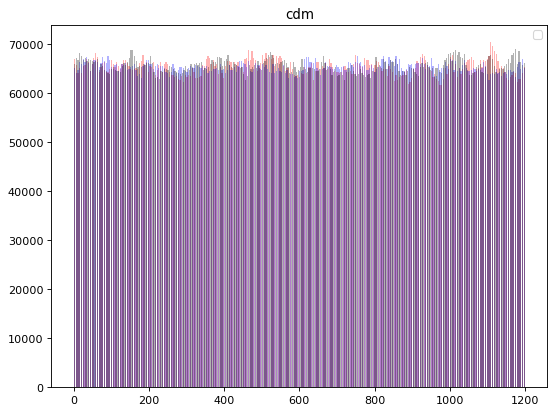

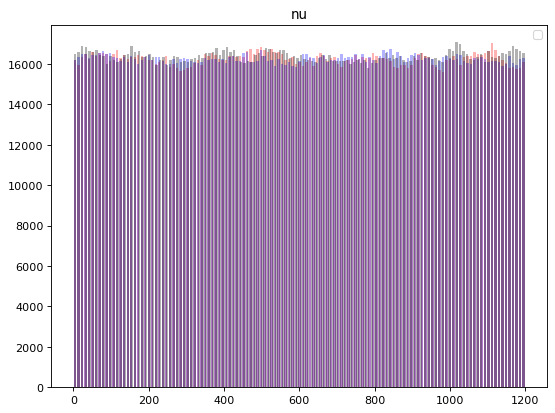

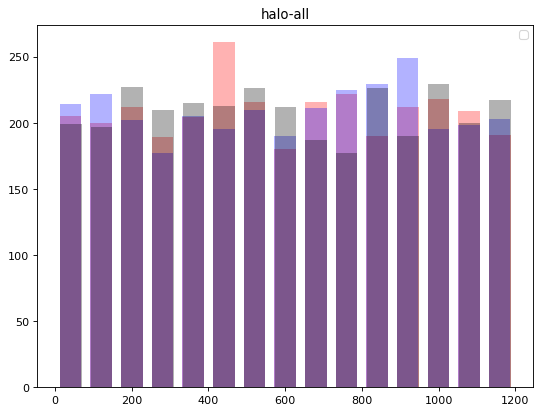

In [17]:
from matplotlib.pyplot import figure


# counts, bins = np.histogram(pos_cdm[:,0], bins=12)
# plt.hist(pos_cdm[:,0], bins, alpha=1)
labels = ['cdm', 'nu', 'halo-all']
l=0
for x in [pos_cdm, pos_nu, pos_halo_all]:
    figure(figsize=(8, 6), dpi=80)
    plt.hist(x=x[:,0], bins='auto', color='red',
                                alpha=0.3, rwidth=0.7)
    plt.hist(x=x[:,1], bins='auto', color='blue',
                                alpha=0.3, rwidth=0.7)
    plt.hist(x=x[:,2], bins='auto', color='black',
                                alpha=0.3, rwidth=0.7)
    # plt.legend()
    plt.title(labels[l])
    l=l+1

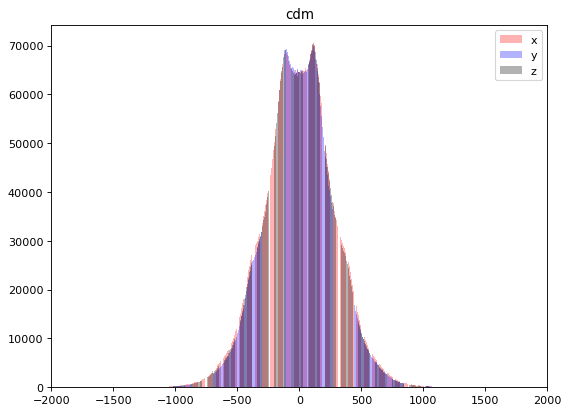

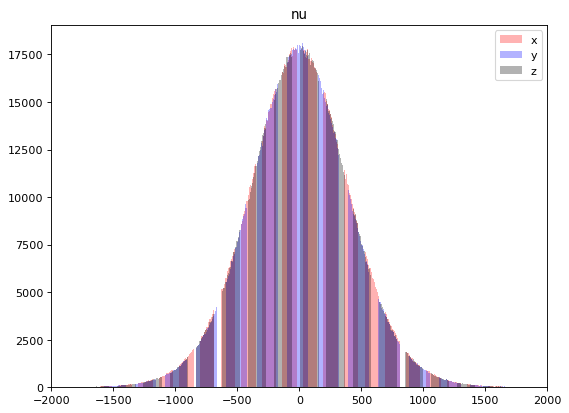

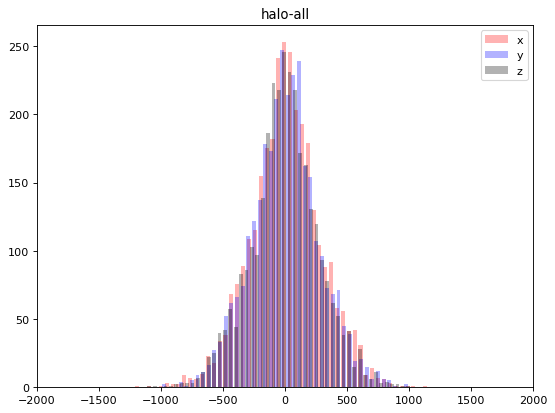

In [32]:
from matplotlib.pyplot import figure


# counts, bins = np.histogram(pos_cdm[:,0], bins=12)
# plt.hist(pos_cdm[:,0], bins, alpha=1)
labels = ['cdm', 'nu', 'halo-all']
l=0
for x in [vel_cdm, vel_nu, vel_halo_all]:
    figure(figsize=(8, 6), dpi=80)
    plt.hist(x=x[:,0], bins='auto', color='red',
                                alpha=0.3, rwidth=0.7,label="x")
    plt.hist(x=x[:,1], bins='auto', color='blue',
                              alpha=0.3, rwidth=0.7,label="y")
    plt.hist(x=x[:,2], bins='auto', color='black',
                                alpha=0.3, rwidth=0.7,label="z")
    plt.legend()
    plt.xlim(-2000,2000)
    plt.title(labels[l])
    l=l+1

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


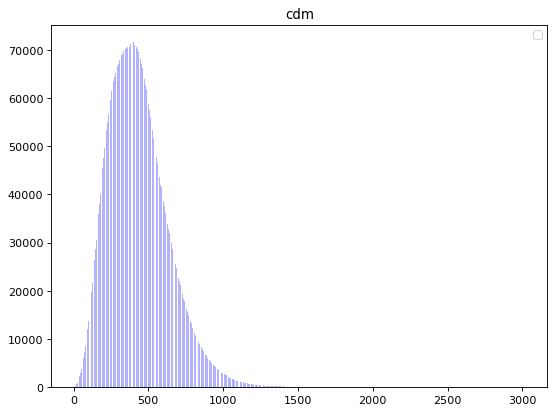

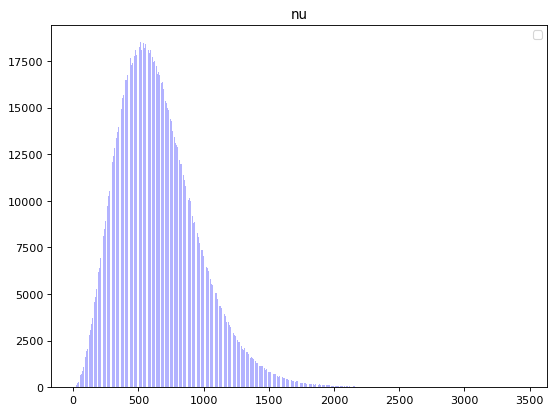

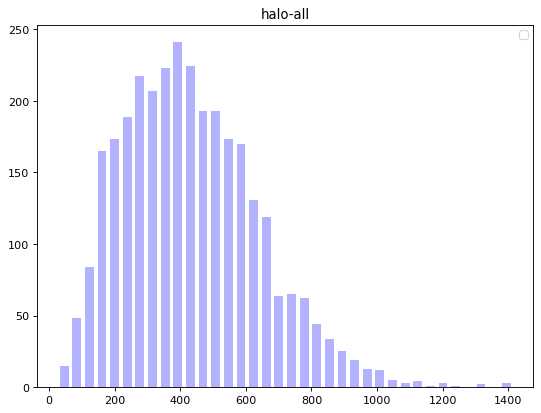

In [9]:
from matplotlib.pyplot import figure


# counts, bins = np.histogram(pos_cdm[:,0], bins=12)
# plt.hist(pos_cdm[:,0], bins, alpha=1)
labels = ['cdm', 'nu', 'halo-all']
l=0
for x in [vel_cdm, vel_nu, vel_halo_all]:
    figure(figsize=(8, 6), dpi=80)
    plt.hist(x=np.sqrt(x[:,0]**2+x[:,1]**2+x[:,2]**2), bins='auto', color='blue',
                                alpha=0.3, rwidth=0.7)
    # plt.hist(x=x[:,1], bins='auto', color='blue',
    #                             alpha=0.3, rwidth=0.7,label="y")
    # plt.hist(x=x[:,2], bins='auto', color='black',
    #                             alpha=0.3, rwidth=0.7,label="z")
    plt.legend()
    # plt.xlim(-2000,2000)
    plt.title(labels[l])
    l=l+1

In [13]:
%%time
memory();

number_smaples = 10;

for ngrid in [20]:
    alpha_halos_cdm=[]
    alpha_halos_nu=[]
    alpha_cdm_nu=[]
    ##
    bulk_vel_cdm=[]
    bulk_vel_nu=[]
    alpha_halos_cdm=[]
    sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
    for i in range(number_smaples):
        sub_box_index = sub_box_lists[i]
        ##### pcl velocities in each cell
        pos_pcl = data[sim_size][sim][bulk_species]['pos']
        vel_pcl = data[sim_size][sim][bulk_species]['vel']
        cdm_vels = obj.vels_in_cell(ngrid, pos_pcl, vel_pcl, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        
        ##### halos velocities in each cell
        pos_halo_all = data[sim_size][sim]['halo']['pos']
        vel_halo_all = data[sim_size][sim]['halo']['vel']
        halos_vels = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        # print(halos_vels)
        
        #### Bulk velocity computation
        bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm,vel_cdm, sub_box_index)
        bulk_vel_nu_i = obj.velocity_bulk(ngrid, pos_nu,vel_nu, sub_box_index)
        
        bulk_vel_cdm .append([ngrid, sub_box_index,bulk_vel_cdm_i] ) # gives the bulk velocity and its 1 sigma as an array!
        bulk_vel_nu.append([ngrid, sub_box_index,bulk_vel_nu_i] ) # gives the bulk velocity and its 1 sigma as an array!
            
        # alpha_halos_cdm.append([ngrid, sub_box_index, obj.alpha_list(vel_halo_all, bulk_vel_cdm_i)]);
        # alpha_halos_nu.append([ngrid, sub_box_index, obj.alpha_list(vel_halo_all, bulk_vel_nu_i)]);
        # alpha_cdm_nu.append([ngrid, sub_box_index, obj.alpha_list(cdm_vels, bulk_vel_nu_i)]);
        # alpha_halos_cdm.append([ngrid, sub_box_index, obj.alpha_list_niayesh(vel_halo_all, bulk_vel_cdm_i)]);
        # alpha_halos_nu.append([ngrid, sub_box_index, obj.alpha_list_niayesh(vel_halo_all, bulk_vel_nu_i)]);
        alpha_cdm_nu.append([ngrid, sub_box_index, obj.alpha_list_niayesh(cdm_vels, bulk_vel_nu_i)]);

        alpha_halos_p1_cdm.append([sub_box_index, obj.alpha_list(vel_halo_p1, bulk_vel_cdm)]);
        alpha_halos_p2_cdm.append([sub_box_index, obj.alpha_list(vel_halo_p2, bulk_vel_cdm)]);

            
            
        

CPU times: user 7.52 s, sys: 1.96 s, total: 9.48 s
Wall time: 9.48 s


In [24]:

memory();
cdms = obj.vels_in_cell(20, pos_cdm, vel_cdm, [2,0,0]);
cdms.shape

memory use: 0.6239662170410156 percentage:  8.4


(2228, 3)

In [43]:
halos = obj.vels_in_cell(20, pos_halo_all, vel_halo_all, [2,0,0]);
halos[:,0]
np.average(halos)

-59.698333333333345

In [46]:
sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
sub_box_lists

array([[21,  2, 28],
       [29,  0, 23],
       [ 0, 24, 27],
       [18, 19, 10],
       [22, 10,  7],
       [26, 18, 15],
       [19, 25, 26],
       [16, 20,  6],
       [ 3,  5, 14],
       [14,  7,  0]])

In [58]:
sub_box_lists = obj.Random_sub_box(ngrid, 30);
ngrid =10
data1 = np.zeros((np.shape(sub_box_lists)[0],2))
for subbox in sub_box_lists:
    print(subbox)
    halos = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all,subbox);
    print()
    cdms = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, subbox);
    data1[:,0] = np.average(halos[:,0])
    data1[:,1] = np.average(cdms[:,0])
    # if 
    # print(subbox, np.average(halos[:,0]), np.average(cdms[:,0]))

ValueError: Sample larger than population or is negative

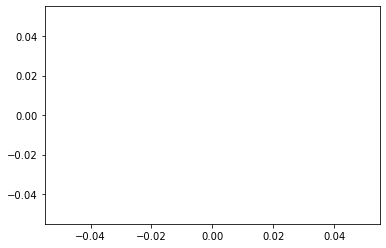

In [54]:
plt.plot(data1[:,0],data1[:,1],"o")

In [19]:
for ngrid in [32]:
    # alpha_halos_cdm=[]
    # alpha_halos_nu=[]
    # alpha_cdm_nu=[]
    # ##
    # bulk_vel_cdm=[]
    # bulk_vel_nu=[]
    sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
    alpha_tot=0
    bulk_vel_tot=0
    for i in range(number_smaples):
        # sub_box_index = sub_box_lists[i]
        # cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        # halos_vels = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        # print(alpha_halos_cdm[0][2][0])
        alpha_tot = alpha_tot + alpha_halos_cdm[i][2][0];
        print(alpha_tot)
        bulk_vel_nu_i = obj.velocity_bulk(ngrid, pos_nu,vel_nu, sub_box_index)
        bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm,vel_cdm, sub_box_index)
        # print(bulk_vel_cdm_i[0][0])
        bulk_vel_tot = bulk_vel_tot+ bulk_vel_cdm_i[0][0]**2 + bulk_vel_cdm_i[0][1]**2 + bulk_vel_cdm_i[0][2]**2;
        
    



531.1197062817398
777.8782128488792
1713.5009289035186
1488.2648778297153
1763.8432940287883
2714.273143252761
1812.2541913793234
2394.1293014095227
2815.864202937502
2718.3025214921045


In [20]:
alpha_tot/bulk_vel_tot

0.0031623804776151057

In [18]:
for ngrid in [32]:
    alpha_halos_cdm=[]
    alpha_halos_nu=[]
    alpha_cdm_nu=[]
    ##
    bulk_vel_cdm=[]
    bulk_vel_nu=[]
    sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
    alpha_tot=0
    bulk_vel_tot=0
    for i in range(number_smaples):
        # sub_box_index = sub_box_lists[i]
        # cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        # halos_vels = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        print(alpha_halos_cdm[0][2][0])
        # alpha_tot = alpha_tot + alpha_halos_cdm[i][2][0];
        print(alpha_tot)
        bulk_vel_nu_i = obj.velocity_bulk(ngrid, pos_nu,vel_nu, sub_box_index)
        bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm,vel_cdm, sub_box_index)
        # print(bulk_vel_cdm_i[0][0])
        bulk_vel_tot = bulk_vel_tot+ bulk_vel_cdm_i[0][0]**2 + bulk_vel_cdm_i[0][1]**2 + bulk_vel_cdm_i[0][2]**2;
        



[array([ 241.37897,  111.79085, -291.0371 ], dtype=float32),
 array([191.78474, 212.46721, 181.76381], dtype=float32)]

In [10]:
bulk_vel_cdm[i][2][0]

array([252.98038, -19.77907, 280.26508], dtype=float32)

In [7]:
from matplotlib.pyplot import figure

# figure(figsize=(8, 6), dpi=80)

for ngrid in [32]:
    for i in range(number_smaples):
        res = alpha_halos_cdm[i][2];
        # bulk_vel_cdm
        # bulk_vel_nu
        # plt.hist(bulk_vel_cdm[i][2][0],label="cell="+str(sub_box_lists[i]))
        # plt.legend()
        print("sub_box_lists:", sub_box_lists[i],"bulk_vel_cdm[i]:",bulk_vel_cdm[i][2][0], "bulk_vel_nu[i]:",bulk_vel_nu[i][2][0])
        

sub_box_lists: [ 5 25  8] bulk_vel_cdm[i]: [-44.17506   27.181595  25.64766 ] bulk_vel_nu[i]: [-25.607075 -18.662897 -19.519375]
sub_box_lists: [1 8 7] bulk_vel_cdm[i]: [ 292.66364  -374.60703   -17.504847] bulk_vel_nu[i]: [ 207.42365 -394.811    -59.27276]
sub_box_lists: [30 29  6] bulk_vel_cdm[i]: [-254.74544  131.52946 -171.85936] bulk_vel_nu[i]: [-234.40569  156.26952 -127.02946]
sub_box_lists: [28 27  2] bulk_vel_cdm[i]: [ 54.166187  85.01353  324.6364  ] bulk_vel_nu[i]: [ 84.85004 146.45479 241.71056]
sub_box_lists: [20  9 22] bulk_vel_cdm[i]: [-164.24161  -126.09723   100.488144] bulk_vel_nu[i]: [-149.56815  -75.58181   46.72005]
sub_box_lists: [10 26  5] bulk_vel_cdm[i]: [256.86432   48.970676 174.3442  ] bulk_vel_nu[i]: [255.8456   -16.143417 187.94385 ]
sub_box_lists: [17 24 25] bulk_vel_cdm[i]: [311.3315   221.92346  108.454865] bulk_vel_nu[i]: [238.89552  87.02274  39.15184]
sub_box_lists: [26 13 26] bulk_vel_cdm[i]: [ -54.2585  -110.90097  -83.14803] bulk_vel_nu[i]: [ -79.

In [8]:
for ngrid in [32]:
    for i in range(number_smaples):
        res = alpha_halos_cdm[i][2];
        # bulk_vel_cdm
        # bulk_vel_nu
        # plt.hist(bulk_vel_cdm[i][2][0],label="cell="+str(sub_box_lists[i]))
        # plt.legend()
        halos_vels = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)
        print("sub_box_lists:", sub_box_lists[i],"bulk_vel_cdm[i]:",bulk_vel_cdm[i][2][0], "bulk_vel_nu[i]:",bulk_vel_nu[i][2][0],"1 halo:", halos_vels)
        
        
        

sub_box_lists: [ 5 25  8] bulk_vel_cdm[i]: [-44.17506   27.181595  25.64766 ] bulk_vel_nu[i]: [-25.607075 -18.662897 -19.519375] 1 halo: []
sub_box_lists: [1 8 7] bulk_vel_cdm[i]: [ 292.66364  -374.60703   -17.504847] bulk_vel_nu[i]: [ 207.42365 -394.811    -59.27276] 1 halo: []
sub_box_lists: [30 29  6] bulk_vel_cdm[i]: [-254.74544  131.52946 -171.85936] bulk_vel_nu[i]: [-234.40569  156.26952 -127.02946] 1 halo: []
sub_box_lists: [28 27  2] bulk_vel_cdm[i]: [ 54.166187  85.01353  324.6364  ] bulk_vel_nu[i]: [ 84.85004 146.45479 241.71056] 1 halo: []
sub_box_lists: [20  9 22] bulk_vel_cdm[i]: [-164.24161  -126.09723   100.488144] bulk_vel_nu[i]: [-149.56815  -75.58181   46.72005] 1 halo: []
sub_box_lists: [10 26  5] bulk_vel_cdm[i]: [256.86432   48.970676 174.3442  ] bulk_vel_nu[i]: [255.8456   -16.143417 187.94385 ] 1 halo: []
sub_box_lists: [17 24 25] bulk_vel_cdm[i]: [311.3315   221.92346  108.454865] bulk_vel_nu[i]: [238.89552  87.02274  39.15184] 1 halo: []
sub_box_lists: [26 13 2

In [17]:
bulk_vel_cdm[i][2][0]

array([ 241.37897,  111.79085, -291.0371 ], dtype=float32)

In [16]:
a = [-94.57076, -78.30432, 221.93622];
b = [-30.901358, -69.10592,  289.38004 ];
np.dot(a,b)/np.dot(b,b)

0.8109588790614242

## PLotting alphas

In [15]:
from matplotlib.pyplot import figure

figure(figsize=(8, 6), dpi=80)

for ngrid in [32]:
    for i in range(10):
        res = alpha_halos_nu[i][2];
        print(res)
        # plt.hist(res)

[-0.14673103 -0.14673103 -0.14673103 ... -0.14673103 -0.14673103
 -0.14673103]
[0.00165242 0.00165242 0.00165242 ... 0.00165242 0.00165242 0.00165242]
[-0.01051393 -0.01051393 -0.01051393 ... -0.01051393 -0.01051393
 -0.01051393]
[0.00859481 0.00859481 0.00859481 ... 0.00859481 0.00859481 0.00859481]
[-0.0409267 -0.0409267 -0.0409267 ... -0.0409267 -0.0409267 -0.0409267]
[0.01462629 0.01462629 0.01462629 ... 0.01462629 0.01462629 0.01462629]
[0.02695287 0.02695287 0.02695287 ... 0.02695287 0.02695287 0.02695287]
[-0.02979151 -0.02979151 -0.02979151 ... -0.02979151 -0.02979151
 -0.02979151]
[-0.01579629 -0.01579629 -0.01579629 ... -0.01579629 -0.01579629
 -0.01579629]
[0.01421813 0.01421813 0.01421813 ... 0.01421813 0.01421813 0.01421813]


<Figure size 640x480 with 0 Axes>

# Functions

In [23]:

# def nested_dict(n, type):
#     if n == 1:
#         return defaultdict(type)
#     else:
#         return defaultdict(lambda: nested_dict(n-1, type))
# data = nested_dict(9, list)

# def norm(x):
#     """norm of a vector"""
#     return np.sqrt(sum(x_i*x_i for x_i in x));

# def dot(x, y):
#     """Dot product of two vectors"""
#     return sum(x_i*y_i for x_i, y_i in zip(x, y));

# def velocity_bulk(ngrid, boxsize, pos,vel, sub_box_index):
#     """computing the bulk velocity in a sub-box using the velocities of objects"""
#     condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
#     condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
#     condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
#     condition_tot = (condition_x) & (condition_y) & (condition_z)
#     vel_grids= np.array([np.average(vel[condition_tot,0]),np.average(vel[condition_tot,1]),np.average(vel[condition_tot,2])])
#     return vel_grids; #/norm(vel_grids);

# def alpha_list(vel, velocity_bulk):
#     """computing alpha for halos/particle using the bulk velocity. The output is an array containing velocities."""
#     alpha = np.zeros((np.shape(vel)[0]));
#     for i in range(np.shape(vel)[0]):
#         alpha[i] = dot(vel[i,:], velocity_bulk)/norm(velocity_bulk)
#     return alpha;

# def halo_selection(data_address, string, mass_limit): # Todo: Produce both halo catalogues together to save memory!
#     """computing the halo population obtained by a mass limit and whether we want larger or smaller halos. The output is 
#     [x,y,z,v_x,v_y,v_z,Rvir,M200b]"""
#     data = np.loadtxt(data_address);
#     if (string == "+"):
#         condition = data[:,20]> mass_limit;
#         halo_pop = np.zeros((np.shape(data[condition])[0],8))
#         for i in range(6):
#             halo_pop[:,i] = data[condition][:,8+i]
#         halo_pop[:,6] = data[condition][:,5] # R_vir
#         halo_pop[:,7] = data[condition][:,20] # Mass
#     if (string == "-"):
#         condition = data[:,20]<= mass_limit;
#         halo_pop = np.zeros((np.shape(data[condition])[0],8))
#         for i in range(6):
#             halo_pop[:,i] = data[condition][:,8+i]
#         halo_pop[:,6] = data[condition][:,5] # R_vir
#         halo_pop[:,7] = data[condition][:,20] # Mass
#     return halo_pop;

# def halos_in_cell_vel(ngrid, boxsize, pos,vel, sub_box_index): 
#     """outputting the velocity of halos in the give sub-box """
#     condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
#     condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
#     condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
#     condition_tot = (condition_x) & (condition_y) & (condition_z)
#     vel_halos =vel[condition_tot];
#     # pos_halos =pos[condition_tot]
#     return vel_halos # For test you can output pos[vel_halos, pos_halos];

# def halo_header(address, column=-1):
#     """Takes the address of the halo and reads the header by default. If the column is specified then just prints the corresponding column!"""
#     f = open(address)
#     header = f.readline()
#     header_list = header.split(' ') #list of columns
#     # print(header_list)
#     if column==-1:
#         for i in range(np.shape(header_list)[0]):
#             print(str(i)+":"+header_list[i])
#     if column!=-1:
#         print(str(column)+":"+header_list[column])

        
# def halo_load(address): # Todo: keep only certain columns! Also rewrite halo_population
#     """Takes the address of the halo and load the file!"""
#     data= np.loadtxt(address)
#     return data;

# def cdm_gadget_load(snapshot, ptype=[1]):
#     """Takes the address of the CDM gadget 2 snapshot and returns the pos and velocity of particles!"""
#     pos = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
#     vel = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
#     # ids = readgadget.read_block(snapshot, "ID  ", ptype)-1   #IDs starting from 0
#     return np.array([pos,vel])



# Loading data

In [51]:
for ngrid in [3]:
    boxsize=1024.;
    mass_limit = 1.e14;
    verbose="y"
    for num in [3]: # the snapshot number start from high redshift
        data_ls1 = []

        for sim in ['Mn_0d6']:
            
            ######################
            snapshot = './../Simulations/'+sim+'/output/snap00'+str(num)+'_cdm'
            halo = np.loadtxt('./../Simulations/'+sim+'/output/halos/out_'+str(num)+'.list')
            ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
            pos_cdm = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
            vel_cdm = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
            ######################
            # Selecting two halo populations:
            halo_pop1=halo_population(halo, "+", mass_limit)
            halo_pop2=halo_population(halo, "-", mass_limit)
            # pos_h1 = halo_pop1[:,0:3]
            # vel_h1 = halo_pop1[:,3:6]
            # Loop over all subboxes
            for i in range(ngrid):
                for j in range(ngrid):
                    for k in range(ngrid):
                        sub_box_index=[i,j,k];
                        # v_c =velocity_bulk(ngrid, boxsize, pos_cdm, vel_cdm, sub_box_index) # Bulk velocity
                        v_c_s =velocity_bulk(ngrid, boxsize, halo_pop1[:,0:3],  halo_pop1[:,3:6], sub_box_index) # Bulk velocity
                        v_c_l =velocity_bulk(ngrid, boxsize, halo_pop2[:,0:3], halo_pop2[:,3:6], sub_box_index) # Bulk velocity
                        v_c =  (v_c_s + v_c_l)/2.;
                        v_diff = (v_c_s - v_c_l);
                        data_ls1.append(dot(v_diff,v_c)/dot(v_c,v_c));
                        # data['alpha_list']['sim='+sim]=
                        # v_h_p1 = halos_in_cell_vel(ngrid, boxsize, halo_pop1[:,0:3], halo_pop1[:,3:6], sub_box_index) # velocities of halos (population 1)
                        # v_h_p2 = halos_in_cell_vel(ngrid, boxsize, halo_pop2[:,0:3], halo_pop2[:,3:6], sub_box_index) # velocities of halos (population 1)
                        # if (np.shape(v_h_p1)[0]==0) & (np.shape(v_h_p2)[0]==0):                        
                        #     data['alpha_list']['mass_limit='+str(mass_limit)]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = 0
                        #     data['alpha_list']['mass_limit='+str(mass_limit)]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = 0
                        #     print("cell:"+str(sub_box_index)+", no halo found!")
                        # else:
                        #     if verbose=="y":
                        #         print("cell:"+str(sub_box_index)+", found "+'\033[91m'+str(np.shape(v_h_p1)[0])+ '\033[0m'+" halo log(M)>"+str(np.round(np.log10(mass_limit),2))+" and "+'\033[34m'+str(np.shape(v_h_p2)[0])+'\033[0m' +" halo log(M)<"+str(np.round(np.log10(mass_limit),2))+", simulation="+sim)
                        #     # data['alpha_list']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = alpha_list(v_h_p1, v_c)
                        #     # data['alpha_list']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = alpha_list(v_h_p2, v_c)
                        #     ### Avg in a cell!
                        #     data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = np.average(alpha_list(v_h_p1, v_c))
                        #     data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = np.average(alpha_list(v_h_p2, v_c))
                            
            print("******************************sim:"+sim+", dx= "+str(boxsize/ngrid)+"[Mpc/h] Done!**************************************")

            

******************************sim:Mn_0d6, dx= 341.3333333333333[Mpc/h] Done!**************************************


In [52]:
for ngrid in [3]:
    boxsize=1024.;
    mass_limit = 1.e14;
    verbose="y"
    for num in [3]: # the snapshot number start from high redshift
        data_ls2 = []
        for sim in ['lcdm']:
            ######################
            snapshot = './../Simulations/'+sim+'/output/snap00'+str(num)+'_cdm'
            halo = np.loadtxt('./../Simulations/'+sim+'/output/halos/out_'+str(num)+'.list')
            ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
            pos_cdm = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
            vel_cdm = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
            ######################
            # Selecting two halo populations:
            halo_pop1=halo_population(halo, "+", mass_limit)
            halo_pop2=halo_population(halo, "-", mass_limit)
            # pos_h1 = halo_pop1[:,0:3]
            # vel_h1 = halo_pop1[:,3:6]
            # Loop over all subboxes
            for i in range(ngrid):
                for j in range(ngrid):
                    for k in range(ngrid):
                        sub_box_index=[i,j,k];
                        # v_c =velocity_bulk(ngrid, boxsize, pos_cdm, vel_cdm, sub_box_index) # Bulk velocity
                        v_c_s =velocity_bulk(ngrid, boxsize, halo_pop1[:,0:3],  halo_pop1[:,3:6], sub_box_index) # Bulk velocity
                        v_c_l =velocity_bulk(ngrid, boxsize, halo_pop2[:,0:3], halo_pop2[:,3:6], sub_box_index) # Bulk velocity
                        v_c =  (v_c_s + v_c_l)/2.;
                        v_diff = (v_c_s - v_c_l);
                        data_ls2.append(dot(v_diff,v_c)/dot(v_c,v_c));
                        # data['alpha_list']['sim='+sim]=
                        # v_h_p1 = halos_in_cell_vel(ngrid, boxsize, halo_pop1[:,0:3], halo_pop1[:,3:6], sub_box_index) # velocities of halos (population 1)
                        # v_h_p2 = halos_in_cell_vel(ngrid, boxsize, halo_pop2[:,0:3], halo_pop2[:,3:6], sub_box_index) # velocities of halos (population 1)
                        # if (np.shape(v_h_p1)[0]==0) & (np.shape(v_h_p2)[0]==0):                        
                        #     data['alpha_list']['mass_limit='+str(mass_limit)]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = 0
                        #     data['alpha_list']['mass_limit='+str(mass_limit)]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = 0
                        #     print("cell:"+str(sub_box_index)+", no halo found!")
                        # else:
                        #     if verbose=="y":
                        #         print("cell:"+str(sub_box_index)+", found "+'\033[91m'+str(np.shape(v_h_p1)[0])+ '\033[0m'+" halo log(M)>"+str(np.round(np.log10(mass_limit),2))+" and "+'\033[34m'+str(np.shape(v_h_p2)[0])+'\033[0m' +" halo log(M)<"+str(np.round(np.log10(mass_limit),2))+", simulation="+sim)
                        #     # data['alpha_list']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = alpha_list(v_h_p1, v_c)
                        #     # data['alpha_list']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = alpha_list(v_h_p2, v_c)
                        #     ### Avg in a cell!
                        #     data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = np.average(alpha_list(v_h_p1, v_c))
                        #     data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = np.average(alpha_list(v_h_p2, v_c))
                            
            print("******************************sim:"+sim+", dx= "+str(boxsize/ngrid)+"[Mpc/h] Done!**************************************")

            

******************************sim:lcdm, dx= 341.3333333333333[Mpc/h] Done!**************************************


In [18]:
import random
ngrid= 100;
a = np.transpose([random.sample(range(1, 100), 3),random.sample(range(1, 100), 3),random.sample(range(1, 100), 3)])




In [19]:
np.shape(a)

(3, 3)

In [20]:
a

array([[43, 45, 53],
       [35, 48, 54],
       [68, 30, 32]])

In [14]:
a[1]

[11, 15, 49]

<ipython-input-56-b7bca3e510e7>:2: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values ":". Passing invalid values is deprecated since 3.4 and will become an error two minor releases later.
  plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")


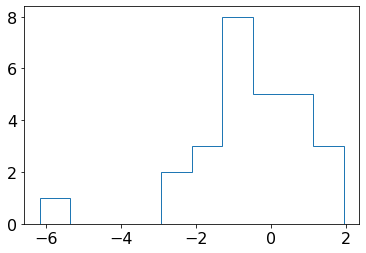

In [56]:

counts, bins = np.histogram(np.array(data_ls2)-np.array(data_ls1), bins=10, range=None, normed=None, weights=None, density=None)
plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")
# plt.legend()
 

<ipython-input-32-129abb71fb07>:2: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values ":". Passing invalid values is deprecated since 3.4 and will become an error two minor releases later.
  plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")


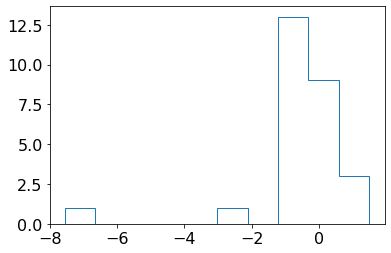

In [32]:

counts, bins = np.histogram(data_ls, bins=10, range=None, normed=None, weights=None, density=None)
plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")
# plt.legend()
 

# $\alpha$ histogram for a given $N_{grid}$

<ipython-input-22-6d078357fcce>:20: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values ":". Passing invalid values is deprecated since 3.4 and will become an error two minor releases later.
  plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")


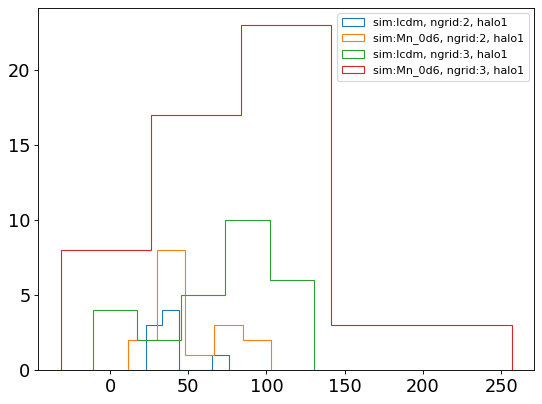

In [22]:
from matplotlib.pyplot import figure
figure(figsize=(8, 6), dpi=80)

for ngrid in [2,3]:
    boxsize=1024.;
    mass_limit = 1.e14;
    verbose="n"
    alpha_all_h1=[]
    alpha_all_h2=[]
    for num in [3]: # the snapshot number start from high redshift
        for sim in ['lcdm', 'Mn_0d6']:
            for i in range(ngrid):
                for j in range(ngrid):
                    for k in range(ngrid):
                        sub_box_index=[i,j,k];
                        alpha_all_h1.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])
                        alpha_all_h2.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])

            counts, bins = np.histogram(alpha_all_h2, bins=5, range=None, normed=None, weights=None, density=None)
            plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")
            plt.legend()
            ######
            # counts, bins = np.histogram(alpha_all_h2, bins=5, range=None, normed=None, weights=None, density=None)
            # plt.stairs(counts, bins, alpha=0.1, hatch='.',fill=True, label="sim:"+sim+", ngrid:"+str(ngrid)+", halo2")
            plt.legend()
# plt.

## $\alpha$ for different $N_{grids}$

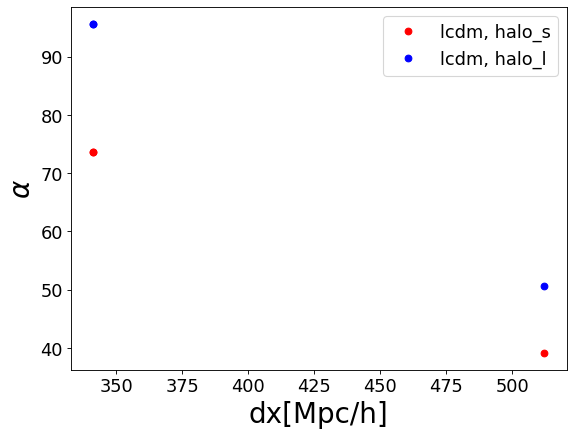

In [24]:
from matplotlib.pyplot import figure
figure(figsize=(8, 6), dpi=80)
# for sim in ['lcdm', 'Mn_0d6']:
for sim in ['lcdm']:

    for ngrid in [2,3]:
        boxsize=1024.;
        mass_limit = 1.e14;
        verbose="n"
        alpha_all_h1=[]
        alpha_all_h2=[]
        for num in [3]: # the snapshot number start from high redshift
            for i in range(ngrid):
                for j in range(ngrid):
                    for k in range(ngrid):
                        sub_box_index=[i,j,k];
                        alpha_all_h1.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])
                        alpha_all_h2.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])

                        
        x1 = [boxsize/ngrid] 
        y1 = [np.average(alpha_all_h1)]
        # print(arr)
        plt.plot(x1,y1,"ro")  
        
        x = [boxsize/ngrid] 
        y = [np.average(alpha_all_h2)]
        plt.plot(x,y,"bo")
            # plt.plot(boxsize/ngrid, np.average(alpha_all_h2), label="sim:"+sim+", halo12)        
    plt.plot(x1,y1,"ro", label=sim+", halo_s")
    plt.plot(x,y,"bo", label=sim+", halo_l")
    
plt.rcParams['xtick.labelsize']=16
plt.rcParams['ytick.labelsize']=16
plt.xlabel("dx[Mpc/h]",fontsize=25)
plt.ylabel(r"$\alpha$",fontsize=25)
plt.legend(fontsize=16)
# plt.

In [14]:
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# import matplotlib.cm as cm
# cmap = cm.get_cmap("jet",lut=6)

# v_c =velocity_bulk(ngrid, boxsize, pos_cdm, vel_cdm, sub_box_index)
# x = np.arange(0, grid, 1)*boxsize/grid
# y = np.arange(0, grid, 1)*boxsize/grid
# plot = plt.pcolormesh(x, y, delta_p[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_p[:,:,z_s])
# # plt.clabel(cset, inline=False)
# plt.title("phase+")
# plt.colorbar(plot)

NameError: name 'grid' is not defined

<Figure size 960x800 with 0 Axes>

## Plot

In [306]:
# # 
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# import matplotlib.cm as cm



# # cmap = cm.get_cmap("jet",lut=6)
# cmap = cm.get_cmap("jet")
# # cmap.set_under("w")

# ####
# x = np.arange(0, grid, 1)*1024./grid
# y = np.arange(0, grid, 1)*1024./grid
# z_s=10
# vmax = 0.05 ;vmin=-0.06
# plot = plt.pcolormesh(x, y, delta_n[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_n[:,:,z_s], cmap='gray')
# # plt.clabel(cset, inline=False)
# plt.title("phase-")
# plt.colorbar(plot)

# ##########################
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# plot = plt.pcolormesh(x, y, delta_p[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_p[:,:,z_s])
# # plt.clabel(cset, inline=False)
# plt.title("phase+")
# plt.colorbar(plot)

# ##########################
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# plot = plt.pcolormesh(x, y, delta_g[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_p[:,:,z_s])
# # plt.clabel(cset, inline=False)
# plt.title("Gaussian")
# plt.colorbar(plot)

In [133]:
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# plot = plt.pcolormesh(x, y, delta_p[:,:,z_s]+delta_n[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_p[:,:,z_s])
# # plt.clabel(cset, inline=False)
# plt.title("phase+ + phase-")
# plt.colorbar(plot)

## Power spectra

In [305]:
# import Pk_library as PKL
# threads=12

# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)

# pk_gev_p= np.loadtxt("./test_runs_Ismael_project/output_seed1//lcdm_p_pk000_delta.dat")
# pk_gev_n= np.loadtxt("./test_runs_Ismael_project/output_seed1//lcdm_n_pk000_delta.dat")
# pk_gev_g= np.loadtxt("./test_runs_Ismael_project/output_seed1/lcdm_g_pk000_delta.dat")
# pk_class= np.loadtxt("./test_runs_Ismael_project/output_class/lcdm_n__classz2_pk.dat")

# kgev=pk_gev_p[:,0]
# # compute power spectrum
# Pk_p = PKL.Pk(delta_p, BoxSize, axis, MAS, threads, verbose)
# Pk_n = PKL.Pk(delta_n, BoxSize, axis, MAS, threads, verbose)
# Pk_g = PKL.Pk(delta_g, BoxSize, axis, MAS, threads, verbose)

# # Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

# # 3D P(k)
# k       = Pk_p.k3D
# Pk0_p     = Pk_p.Pk[:,0] #monopole
# Pk0_n     = Pk_n.Pk[:,0] #monopole
# Pk0_g     = Pk_g.Pk[:,0] #monopole

# plt.loglog(k,Pk0_p,"o",label="Pylians, phase+")
# plt.loglog(k,Pk0_n,"o",label="Pylians, phase-")
# plt.loglog(k,Pk0_g,"o",label="Pylians, Gaussian")
# plt.loglog(pk_class[:,0],pk_class[:,1],"-.",label="CLASS")

# plt.loglog(kgev,pk_gev_p[:,1]*2.*np.pi**2/kgev**3,"*",label="phase+, gev")
# plt.loglog(kgev,pk_gev_n[:,1]*2.*np.pi**2/kgev**3,"*",label="phase-, gev")
# plt.loglog(kgev,pk_gev_g[:,1]*2.*np.pi**2/kgev**3,"*",label="Gaussian, gev")


# dk = kgev - roll(kgev,-1)
# #### bins class
# plt.loglog(pk_class[:,0],pk_class[:,1],"-.",label="CLASS")


# # pk_gev_p= np.loadtxt("./test_runs_Ismael_project/output_seed2//lcdm_p_pk000_delta.dat")
# # pk_gev_n= np.loadtxt("./test_runs_Ismael_project/output_seed2//lcdm_n_pk000_delta.dat")
# # pk_gev_g= np.loadtxt("./test_runs_Ismael_project/output_seed2/lcdm_g_pk000_delta.dat")


# # plt.loglog(kgev,pk_gev_p[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, phase+, gev")
# # plt.loglog(kgev,pk_gev_n[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, phase-, gev")
# # plt.loglog(kgev,pk_gev_g[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, Gaussian, gev")

# # plt.loglog(k,Pk0_p,"*",label="seed2, phase+")
# # plt.loglog(k,Pk0_n,"*",label="seed2, phase-")
# # plt.loglog(k,Pk0_g,"*",label="seed2, Gaussian")


# plt.ylim(0.01,10)
# plt.xlim(1.e-3,1)

# plt.legend(fontsize=16)
# plt.xlabel("$k[h/Mpc]$",fontsize=24)
# plt.ylabel("$P[Mpc^3/h^3]$",fontsize=24)


In [304]:
# import Pk_library as PKL
# threads=12

# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)

# pk_gev_p= np.loadtxt("./test_runs_Ismael_project/output_seed1//lcdm_p_pk000_delta.dat")
# pk_gev_n= np.loadtxt("./test_runs_Ismael_project/output_seed1//lcdm_n_pk000_delta.dat")
# pk_gev_g= np.loadtxt("./test_runs_Ismael_project/output_seed1/lcdm_g_pk000_delta.dat")
# pk_class= np.loadtxt("./test_runs_Ismael_project/output_class/lcdm_n__classz2_pk.dat")

# kgev=pk_gev_p[:,0]
# # # compute power spectrum
# # Pk_p = PKL.Pk(delta_p, BoxSize, axis, MAS, threads, verbose)
# Pk_n = PKL.Pk(delta_n, BoxSize, axis, MAS, threads, verbose)
# # Pk_g = PKL.Pk(delta_g, BoxSize, axis, MAS, threads, verbose)

# # Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

# # 3D P(k)
# # k       = Pk_p.k3D
# # Pk0_p     = Pk_p.Pk[:,0] #monopole
# # Pk0_n     = Pk_n.Pk[:,0] #monopole
# # Pk0_g     = Pk_g.Pk[:,0] #monopole

# # plt.loglog(k,Pk0_p,"o",label="Pylians, phase+")
# # plt.loglog(k,Pk0_n,"o",label="Pylians, phase-")
# # plt.loglog(k,Pk0_g,"o",label="Pylians, Gaussian")
# # plt.loglog(pk_class[:,0],pk_class[:,1],"-.",label="CLASS")

# plt.loglog(kgev,pk_gev_p[:,1]*2.*np.pi**2/kgev**3,"*",label="phase+, gev")
# # plt.loglog(kgev,pk_gev_n[:,1]*2.*np.pi**2/kgev**3,"*",label="phase-, gev")
# # plt.loglog(kgev,pk_gev_g[:,1]*2.*np.pi**2/kgev**3,"*",label="Gaussian, gev")


# # dk = kgev - roll(kgev,-1)
# #### bins class
# plt.loglog(pk_class[:,0],pk_class[:,1],"-.",label="CLASS")


# # pk_gev_p= np.loadtxt("./test_runs_Ismael_project/output_seed2//lcdm_p_pk000_delta.dat")
# # pk_gev_n= np.loadtxt("./test_runs_Ismael_project/output_seed2//lcdm_n_pk000_delta.dat")
# # pk_gev_g= np.loadtxt("./test_runs_Ismael_project/output_seed2/lcdm_g_pk000_delta.dat")


# # plt.loglog(kgev,pk_gev_p[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, phase+, gev")
# # plt.loglog(kgev,pk_gev_n[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, phase-, gev")
# # plt.loglog(kgev,pk_gev_g[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, Gaussian, gev")

# # plt.loglog(k,Pk0_p,"*",label="seed2, phase+")
# # plt.loglog(k,Pk0_n,"*",label="seed2, phase-")
# # plt.loglog(k,Pk0_g,"*",label="seed2, Gaussian")


# plt.ylim(0.01,10)
# plt.xlim(1.e-3,1)

# plt.legend(fontsize=16)
# plt.xlabel("$k[h/Mpc]$",fontsize=24)
# plt.ylabel("$P[Mpc^3/h^3]$",fontsize=24)


Text(0, 0.5, '$P[Mpc^3/h^3]$')

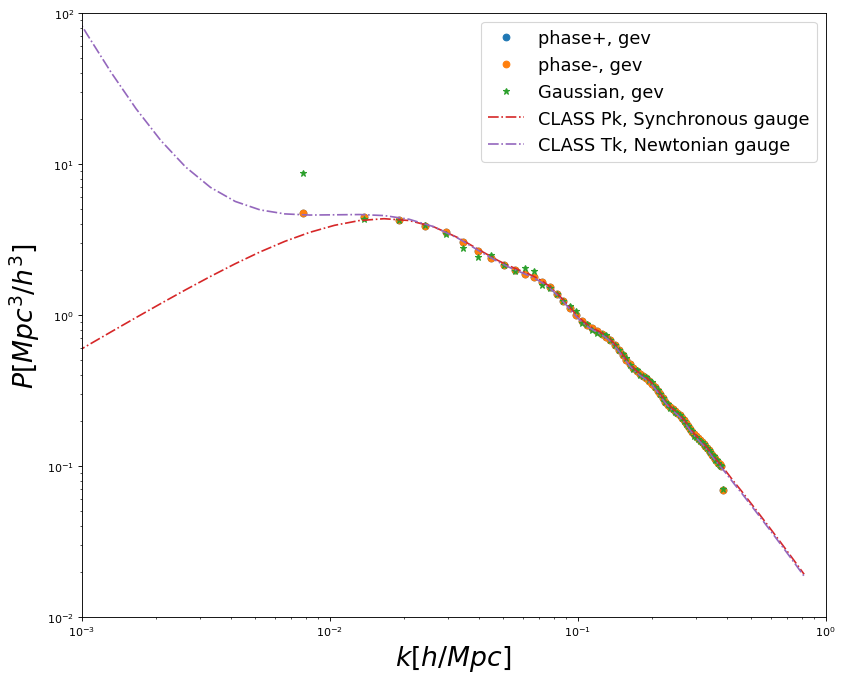

In [212]:
# def nested_dict(n, type):
#     if n == 1:
#         return defaultdict(type)
#     else:
#         return defaultdict(lambda: nested_dict(n-1, type))
    
# data = nested_dict(4, list)

    # read header
    # header   = readgadget.header(snapshot)
    # BoxSize  = header.boxsize/1e3  #Mpc/h
    # Nall     = header.nall         #Total number of particles
    # Masses   = header.massarr*1e10 #Masses of the particles in Msun/h
    # Omega_m  = header.omega_m      #value of Omega_m
    # Omega_l  = header.omega_l      #value of Omega_l
    # h        = header.hubble       #value of h
    # redshift = header.redshift     #redshift of the snapshot
    # Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l)#Value of H(z) in km/s/(Mpc/h)
    # read positions, velocities and IDs of the particles

In [2]:
import numpy as np
class massive_neutrinos:
    """
    Class for massive neutrino project
    """
    def __init__(self):
        # self.comm = MPI.COMM_WORLD
        return
    
    def nested_dict(self, n, type):
        """ Definition of nested dictionary """
        if n == 1:
            return defaultdict(type)
        else:
            return defaultdict(lambda: nested_dict(n-1, type))
        
    def norm(self, x):
        """ norm of a vector """
        return np.sqrt(sum(x_i*x_i for x_i in x));

    def dot(self, x, y):
        """Dot product of two vectors"""
        return sum(x_i*y_i for x_i, y_i in zip(x, y));
    
    def dist(self, x, y):
        """Distance of two points"""
        return self.norm(np.subtract(x,y)) ;
    
    def halo_selection(self, data, string, mass_limit): 
        """ outputting a halo population obtained by a mass limit and whether we want larger or smaller halos.
            input: data (halo catalogue from Rockstar), a string being + or -, and mass limit in solar mass.
            output: A new catalogue with [x,y,z,v_x,v_y,v_z,Rvir,M200b] of halo population
        """
        if (string == "+"):
            condition = data[:,20]> mass_limit;
            halo_pop = np.zeros((np.shape(data[condition])[0],8))
            for i in range(6):
                halo_pop[:,i] = data[condition][:,8+i]
            halo_pop[:,6] = data[condition][:,5] # R_vir
            halo_pop[:,7] = data[condition][:,20] # Mass
        if (string == "-"):
            condition = data[:,20]<= mass_limit;
            halo_pop = np.zeros((np.shape(data[condition])[0],8))
            for i in range(6):
                halo_pop[:,i] = data[condition][:,8+i]
            halo_pop[:,6] = data[condition][:,5] # R_vir
            halo_pop[:,7] = data[condition][:,20] # Mass
        return halo_pop;


In [7]:
obj = massive_neutrinos();
x = [0,0,0]
y = [3,3,3]
obj.dist(x,y)

5.196152422706632

In [16]:
x = [0,0,0]
y = [1,1,1]

In [13]:
x[:]-y[:]

TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [17]:
np.subtract(x,y)

array([-1, -1, -1])

In [4]:
import random

import numpy as np

In [2]:
a = [1,2,3,4,5]
np.average(a)

3.0

In [3]:
np.std(a)

1.4142135623730951

In [2]:
 def Random_sub_box(ngrid, number):
        """Takes the number of grids and return N randomly chosen sub-box indices! 
        """
        res = np.transpose([random.sample(range(0, ngrid), number),random.sample(range(0, ngrid), number),random.sample(range(0, ngrid), number)])
        return res

In [6]:
a = Random_sub_box(4, 3)

In [11]:
a

array([[1, 3, 0],
       [2, 1, 3],
       [0, 2, 1]])

In [10]:
for i,j,k in a:
    print(i,j,k)

1 3 0
2 1 3
0 2 1
